<a href="https://colab.research.google.com/github/AliRaza-Dev678/AliRaza-Dev678/blob/main/Face_Mask_Detection_using_CNN_DeepLearning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install kaggle

In [2]:
# kaggle.json_file_configuration
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# Api to fetch the dataset from kaggle
! kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 98% 160M/163M [00:00<00:00, 1.67GB/s]
100% 163M/163M [00:00<00:00, 1.66GB/s]


In [4]:
# Extracting the compressed dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'
with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


**Importing Libraries**

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mping
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')

In [8]:
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_3373.jpg', 'with_mask_3192.jpg', 'with_mask_2900.jpg', 'with_mask_1201.jpg', 'with_mask_763.jpg']
['with_mask_607.jpg', 'with_mask_2799.jpg', 'with_mask_1629.jpg', 'with_mask_2811.jpg', 'with_mask_235.jpg']


In [9]:
without_mask_files = os.listdir('/content/data/without_mask')

In [10]:
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2361.jpg', 'without_mask_438.jpg', 'without_mask_300.jpg', 'without_mask_2061.jpg', 'without_mask_2297.jpg']
['without_mask_2894.jpg', 'without_mask_2247.jpg', 'without_mask_3755.jpg', 'without_mask_2783.jpg', 'without_mask_341.jpg']


In [11]:
# Making sure that the dataset is balanced
print('Number of images with mask: ', len(with_mask_files))
print('Number of images without mask: ', len(without_mask_files))

Number of images with mask:  3725
Number of images without mask:  3828


**Creating Labels for two classes of images**

**0 --> without mask**

**1 --> with mask**

---



In [12]:
# If the two classes are not in the same file than labels are assigned in this way

with_mask_labels = [1]*3725
                                     # These are in the form of Lists now
without_mask_labels = [0]*3828

In [13]:
print(with_mask_labels[0:5])

[1, 1, 1, 1, 1]


In [14]:
print(without_mask_labels[0:5])

[0, 0, 0, 0, 0]


In [15]:
print(len(with_mask_labels))

3725


In [16]:
print(len(without_mask_labels))

3828


In [17]:
# Combining both lists of labels
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

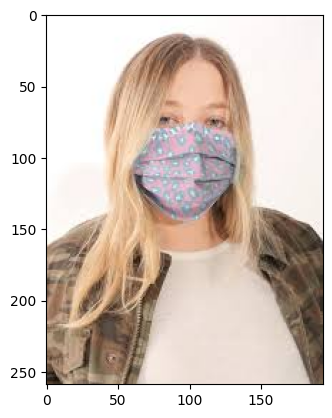

In [18]:
# Displaying image with mask
img = plt.imread('/content/data/with_mask/with_mask_2807.jpg')   # plt.imread & mping.imread gives same results
plt.imshow(img)
plt.show()

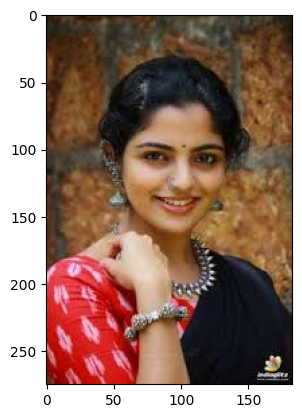

In [19]:
# Displaying image with mask
img = mping.imread('/content/data/without_mask/without_mask_1623.jpg')
plt.imshow(img)
plt.show()

**Image Processing**

**Image Resizing**

**Convert images to Numpy array**

In [20]:
# converting with_mask and without_mask images to numpy array and resize them to (128,128)

with_mask_path = '/content/data/with_mask/' # must use forward slash at the end of path bcz after it the number of image comes

data = []

for img_file in with_mask_files:
  image = Image.open(with_mask_path + img_file) # every time when loop iterate img_file contains the image number and image extention like (with_mask_1623.jpg)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)


without_mask_path = '/content/data/without_mask/'
for img_file in without_mask_files:
  image = Image.open(without_mask_path + img_file) # every time when loop iterate img_file contains the image number and image extention like (with_mask_1623.jpg)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [21]:
type(data)

list

In [22]:
type(data[0])

numpy.ndarray

array([[[ 49,  61,  73],
        [ 49,  61,  73],
        [ 49,  61,  75],
        ...,
        [ 69,  85, 101],
        [ 67,  83,  99],
        [ 66,  82,  98]],

       [[ 49,  61,  73],
        [ 48,  60,  73],
        [ 48,  61,  73],
        ...,
        [ 70,  86, 102],
        [ 68,  84, 100],
        [ 67,  83,  99]],

       [[ 49,  61,  73],
        [ 48,  60,  72],
        [ 48,  61,  70],
        ...,
        [ 70,  86, 102],
        [ 69,  85, 101],
        [ 68,  84, 100]],

       ...,

       [[ 46,  55,  64],
        [ 51,  63,  72],
        [ 59,  70,  79],
        ...,
        [ 29,  35,  35],
        [ 37,  41,  42],
        [ 47,  50,  56]],

       [[ 47,  59,  68],
        [ 54,  66,  75],
        [ 64,  74,  83],
        ...,
        [ 34,  38,  40],
        [ 39,  43,  46],
        [ 50,  54,  57]],

       [[ 49,  63,  71],
        [ 56,  69,  78],
        [ 65,  75,  84],
        ...,
        [ 45,  49,  52],
        [ 42,  46,  49],
        [ 49,  54,  56]]], dtype=uint8)
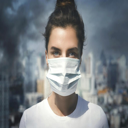

In [23]:
data[0]

In [24]:
data[0].shape

(128, 128, 3)

**Converting the image list and labels list into numpy array**

In [25]:
x = np.array(data)
y = np.array(labels)

In [26]:
type(x)
type(y)

numpy.ndarray

In [27]:
print(x.shape, y.shape)

(7553, 128, 128, 3) (7553,)


**Train Test Split**

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [29]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(6042, 128, 128, 3) (1511, 128, 128, 3) (6042,) (1511,)


**Scaling the data**

In [30]:
# scaling range of images from 0 -- 255 to 0 -- 1
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [31]:
x_train_scaled    # Now the image data is in the range of 0 -- 1

array([[[[0.70196078, 0.6627451 , 0.63921569],
         [0.67058824, 0.61568627, 0.58431373],
         [0.68627451, 0.63137255, 0.58823529],
         ...,
         [0.12941176, 0.12941176, 0.1254902 ],
         [0.12941176, 0.1254902 , 0.11764706],
         [0.14117647, 0.1372549 , 0.12941176]],

        [[0.84313725, 0.78039216, 0.7372549 ],
         [0.87843137, 0.79607843, 0.74509804],
         [0.86666667, 0.78431373, 0.72941176],
         ...,
         [0.14509804, 0.14509804, 0.13333333],
         [0.1372549 , 0.13333333, 0.1254902 ],
         [0.13333333, 0.13333333, 0.1254902 ]],

        [[0.91372549, 0.84313725, 0.79607843],
         [0.90196078, 0.81176471, 0.76078431],
         [0.81960784, 0.7372549 , 0.68235294],
         ...,
         [0.14509804, 0.14509804, 0.1372549 ],
         [0.16470588, 0.16470588, 0.15294118],
         [0.15294118, 0.14901961, 0.14117647]],

        ...,

        [[0.05882353, 0.05490196, 0.07843137],
         [0.05882353, 0.05490196, 0.0745098 ]

**Building a Convulational Neural Network (CNN)**

In [32]:
# Importing Libraries for our CNN
import tensorflow as tf
from tensorflow import keras

In [46]:
import tensorflow as tf
from tensorflow import keras

# Setting up the layers of our model

number_of_classes = 2

model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size = (3,3), activation = 'relu', input_shape = (128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size = (2,2)))

model.add(keras.layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'))
model.add(keras.layers.MaxPooling2D(pool_size = (2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation = 'relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation = 'relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(number_of_classes, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# Compiling our model
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [50]:
# Fitting our model on training data
history = model.fit(x_train_scaled, y_train, validation_split = 0.1, epochs = 5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.7041 - loss: 0.6268 - val_accuracy: 0.8942 - val_loss: 0.2776
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8865 - loss: 0.2877 - val_accuracy: 0.8331 - val_loss: 0.3695
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8981 - loss: 0.2623 - val_accuracy: 0.9140 - val_loss: 0.2127
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9206 - loss: 0.1978 - val_accuracy: 0.9240 - val_loss: 0.2161
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9367 - loss: 0.1558 - val_accuracy: 0.9157 - val_loss: 0.2245


**Model Evaluation**

In [36]:
loss, accuracy = model.evaluate(x_test_scaled, y_test)
print('Model Accuracy on testing data: ', accuracy*100,'%')

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9142 - loss: 0.2433
Model Accuracy on testing data:  92.45532751083374 %


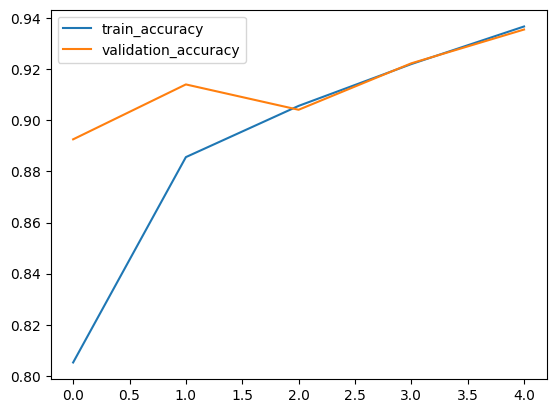

In [37]:
# plotting the accuracy value

plt.plot(history.history['accuracy'], label = 'train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation_accuracy')
plt.legend()
plt.show()

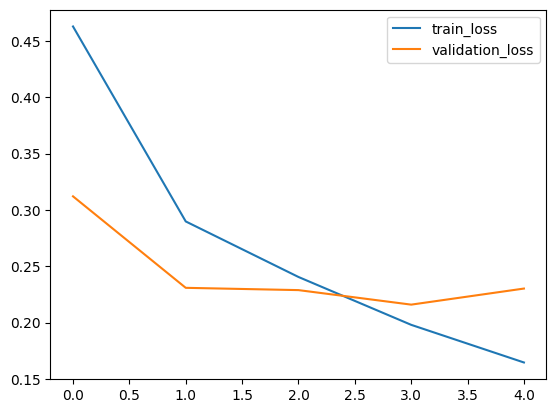

In [38]:
# plotting the loss value

plt.plot(history.history['loss'], label = 'train_loss')
plt.plot(history.history['val_loss'], label = 'validation_loss')
plt.legend()
plt.show()

**Predictive System**

Enter the path of image to be predicted: /content/data/without_mask/without_mask_1623.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
[[0.96944153 0.03055844]]
0
The person in the image is not wearing mask


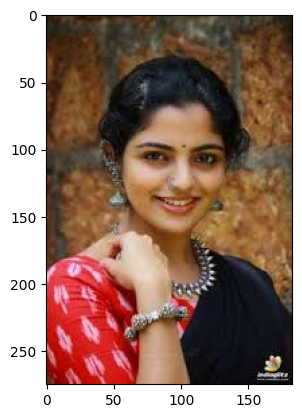

In [58]:
input_image_path = input('Enter the path of image to be predicted: ')

input_image = plt.imread(input_image_path)
plt.imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

prediction = model.predict(input_image_reshaped)
print(prediction)

prediction_label = np.argmax(prediction)
print(prediction_label)

if prediction_label == 0:
  print('The person in the image is not wearing mask')
else:
  print('The person in the image is wearing a mask')

### Verifying Model Performance on a Known Image from Dataset

Testing with image: /content/data/without_mask/without_mask_1623.jpg


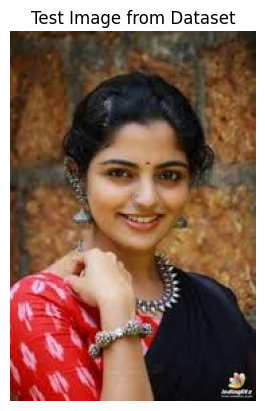

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Raw prediction output: [[0.9078753  0.22745764]]
Predicted label (0=without mask, 1=with mask): 0
The model predicts: The person in the image is not wearing a mask


In [40]:
# Test with a known image from the dataset (e.g., without_mask_1623.jpg)
# This uses the same preprocessing logic as the Streamlit app

input_image_path_test = '/content/data/without_mask/without_mask_1623.jpg'
print(f"Testing with image: {input_image_path_test}")

# Load image using PIL for consistency with Streamlit
input_image_test = Image.open(input_image_path_test)
input_image_test = input_image_test.convert('RGB') # Ensure RGB format

# Display the image
plt.imshow(input_image_test)
plt.title('Test Image from Dataset')
plt.axis('off')
plt.show()

# Preprocess the image for model prediction
input_image_test = input_image_test.resize((128,128)) # Resize using PIL
input_image_array_test = np.array(input_image_test)
input_image_scaled_test = input_image_array_test / 255
input_image_reshaped_test = np.reshape(input_image_scaled_test, [1,128,128,3])

# Make prediction
prediction_test = model.predict(input_image_reshaped_test)
prediction_label_test = np.argmax(prediction_test)

print(f"Raw prediction output: {prediction_test}")
print(f"Predicted label (0=without mask, 1=with mask): {prediction_label_test}")

if prediction_label_test == 0:
  print('The model predicts: The person in the image is not wearing a mask')
else:
  print('The model predicts: The person in the image is wearing a mask')


In [41]:
!pip install streamlit pyngrok pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 138.3 MB/s eta 0:00:00


In [59]:
%%writefile app.py
import streamlit as st
from PIL import Image
import time
import numpy as np
import tensorflow as tf
import cv2

# Load the trained model
model = tf.keras.models.load_model('/content/model.h5')

# ---------------- PAGE CONFIG ----------------
st.set_page_config(
    page_title="Face Mask Detection",
    page_icon="😷",
    layout="centered"
)

# ---------------- CUSTOM CSS ----------------
st.markdown("""
<style>
.main {
    background: linear-gradient(to right, #1e3c72, #2a5298); /* Deep blue gradient */
    color: white;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
}
.title {
    text-align: center;
    font-size: 45px;
    font-weight: bold;
    color: #f0f2f6; /* Light grey */
    text-shadow: 2px 2px 4px rgba(0,0,0,0.5);
    margin-bottom: 20px;
}
.subtitle {
    text-align: center;
    font-size: 18px;
    color: #c9d6df; /* Muted light blue */
    margin-bottom: 30px;
}
.result-box {
    padding: 25px;
    border-radius: 15px;
    text-align: center;
    font-size: 24px;
    font-weight: bold;
    margin-top: 30px;
    box-shadow: 0 4px 8px rgba(0, 0, 0, 0.4);
    transition: all 0.3s ease-in-out;
}
.mask {
    background-color: #2ECC71; /* Emerald Green */
    color: white;
    border: 2px solid #28A745;
}
.no-mask {
    background-color: #E74C3C; /* Alizarin Red */
    color: white;
    border: 2px solid #DC3545;
}
.stRadio > label {
    font-size: 18px;
    font-weight: bold;
    color: #f0f2f6;
}
</style>
""", unsafe_allow_html=True)

# ---------------- HEADER ----------------
st.markdown('<p class="title">😷 Face Mask Detection System</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">Upload an image or use camera to detect mask</p>', unsafe_allow_html=True)

st.divider()

# ---------------- INPUT OPTIONS ----------------
option = st.radio("Choose Input Method:", ["Upload Image", "Use Camera"])

image = None

if option == "Upload Image":
    uploaded_file = st.file_uploader("Upload Image", type=["jpg", "png", "jpeg"])
    if uploaded_file:
        image = Image.open(uploaded_file)

elif option == "Use Camera":
    camera_image = st.camera_input("Take a Picture")
    if camera_image:
        image = Image.open(camera_image)

# ---------------- DISPLAY IMAGE ----------------
if image:
    st.image(image, caption="Input Image", use_container_width=True)

    # ---------------- LOADING ----------------
    with st.spinner("Analyzing Image..."):
        time.sleep(2)

        # Preprocess the image for model prediction
        image = image.resize((128,128)) # Resize using PIL for consistency with training
        image = image.convert('RGB') # Ensure image is in RGB format
        input_image_array = np.array(image)
        input_image_scaled = input_image_array / 255
        input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

        # Make prediction
        prediction = model.predict(input_image_reshaped)
        st.write(f"Raw Prediction Output: {prediction}") # Debugging line
        prediction_label = np.argmax(prediction)

        # Determine result based on prediction
        if prediction_label == 1:
            result = "Mask"
        else:
            result = "No Mask"

    # ---------------- RESULT ----------------
    if result == "Mask":
        st.markdown('<div class="result-box mask">✅ Mask Detected</div>', unsafe_allow_html=True)
    else:
        st.markdown('<div class="result-box no-mask">❌ No Mask Detected</div>', unsafe_allow_html=True)

# ---------------- SIDEBAR ----------------
st.sidebar.title("📌 About")
st.sidebar.info(
    "This AI app detects whether a person is wearing a face mask using a CNN model."
)

st.sidebar.title("👨‍💻 Developer")
st.sidebar.write("Laraib Qandeel | ML Engineer")

st.sidebar.title("⚙️ Instructions")
st.sidebar.write("1. Upload image or use camera\n2. Wait for result\n3. See prediction")

Overwriting app.py


In [55]:
from pyngrok import ngrok
import os
import subprocess

# Terminate any existing ngrok processes to free up resources
# This helps in avoiding the 'too many endpoints' error
subprocess.run(['killall', 'ngrok'], stderr=subprocess.DEVNULL, stdout=subprocess.DEVNULL)

# Terminate any existing streamlit processes to ensure changes are applied
subprocess.run(['pkill', '-f', 'streamlit'], stderr=subprocess.DEVNULL, stdout=subprocess.DEVNULL)

# Get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("2waX19uMhWYlatvWnwNfxcPchYf_4Nv6j4Kvb3W7qT6BHSY34")

public_url = ngrok.connect(addr='8501')
print('Public URL:', public_url)

# Ensure Streamlit is run in the background and its output is redirected to avoid blocking
!streamlit run app.py &>/dev/null&

Public URL: NgrokTunnel: "https://e45b-34-169-105-253.ngrok-free.app" -> "http://localhost:8501"


In [56]:
import os

model_path = '/content/model.h5'

# Ensure the model directory exists, if applicable (not strictly needed for /content/)
# os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Always resave the model after retraining with new architecture
print(f"Resaving the model to {model_path}...")
model.save(model_path)
print("Model resaved successfully.")

Resaving the model to /content/model.h5...
Model resaved successfully.


In [57]:
!cat app.py

import streamlit as st
from PIL import Image
import time
import numpy as np
import tensorflow as tf
import cv2

# Load the trained model
model = tf.keras.models.load_model('/content/model.h5')

# ---------------- PAGE CONFIG ----------------
st.set_page_config(
    page_title="Face Mask Detection",
    page_icon="😷",
    layout="centered"
)

# ---------------- CUSTOM CSS ----------------
st.markdown("""
<style>
.main {
    background: linear-gradient(to right, #1e3c72, #2a5298); /* Deep blue gradient */
    color: white;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
}
.title {
    text-align: center;
    font-size: 45px;
    font-weight: bold;
    color: #f0f2f6; /* Light grey */
    text-shadow: 2px 2px 4px rgba(0,0,0,0.5);
    margin-bottom: 20px;
}
.subtitle {
    text-align: center;
    font-size: 18px;
    color: #c9d6df; /* Muted light blue */
    margin-bottom: 30px;
}
.result-box {
    padding: 25px;
    border-radius: 15px;
    text-align: center;
    font-

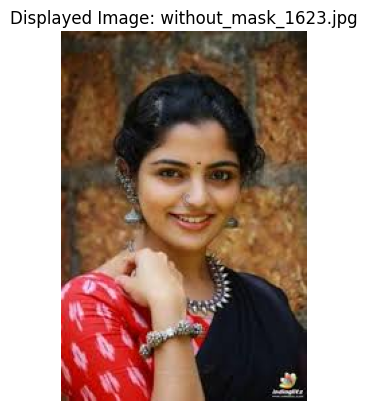

In [60]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = '/content/data/without_mask/without_mask_1623.jpg'
img = Image.open(image_path)
plt.imshow(img)
plt.title('Displayed Image: without_mask_1623.jpg')
plt.axis('off')
plt.show()